<a href="https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/20260905/notebooks/nb1_scientific_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 직접 만드는 "Claude Code식" 과학 에이전트 — 신약개발 자율 파이프라인

**6일차 실습 · 대규모 언어모델과 신약개발 (2026)**

이 노트북은 LLM 에이전트를 **처음부터** 만들어 본다. 챗봇이 아니라 **도구(tool)를 실행하는 워커**로서,
자연어 목표 하나("EGFR 저해제 후보를 조사하고 약물성을 평가하라")를 받아
**타겟 조사 → 후보 검색 → ADMET 평가 → 보고서 작성**까지 스스로 수행한다.

## 학습 목표
1. **함수 호출(function calling)** 로 LLM에 도구를 등록하는 방법 — JSON schema 설계.
2. 신약개발 실무 도구 5종을 **실제 공개 API/실계산** 으로 구현: PubMed · UniProt · ChEMBL · RDKit 물성 · 규칙기반 ADMET.
3. **에이전트 루프(ReAct: Reason→Act→Observe)** 구조 — LLM이 어떤 도구를 언제 부를지 스스로 결정.
4. 엔드투엔드 자율 사이클을 돌리고, **구조 그림 + 보고서**를 자동 생성.
5. 에이전트 **고도화** — 도구 추가, 실패 디버깅(재시도/폴백), 안전(권한 최소화·키 격리·감사로그).

## 왜 지금(2026)인가 — "챗봇 → 워커"
2026년 프론티어 모델(Claude Opus 5/Sonnet 5, GPT-5.x, Gemini 3)의 핵심 흐름은 두 가지다:
(a) **추론(reasoning) 기본 탑재**, (b) **에이전틱(agentic) — 모델이 '대화 상대'에서 '도구를 실행하는 작업자'로**.
`Claude for Life Sciences`, `TxAgent/Agentic-Tx`, `Google AI co-scientist`, `PharmAgents`/`MADD`/`DiscoVerse`
같은 다중 에이전트 신약개발 시스템이 이 방향의 사례다. 이 노트북은 그 최소 골격을 손으로 만들어 본다.
(모델 버전은 빠르게 바뀜 — 2026.9 시점 확인 권장.)

> ⚠️ **무-날조(No-Fabrication) 원칙.** 이 노트북의 모든 수치·식별자(PMID, UniProt accession, ChEMBL ID,
> SMILES, 물성값)는 **실제 API 응답 또는 RDKit 실계산값** 이다. LLM이 IC50·ID·PMID를 지어내지 않는다.
> ADMET은 **규칙기반(Lipinski/Veber 등) 플래그**이며 ML "예측"이 아니다 — 마지막 한계 섹션 참고.

## 0. 설치 & 임포트

**완전 무료.** Colab에서는 `rdkit`, `requests` 만 있으면 무-키(no API key) 경로로 전체가 돌아간다 (0원).
사용하는 데이터 도구는 전부 **무료 공개 API/오픈소스**다: PubMed(NCBI E-utilities), UniProt REST, ChEMBL REST, RDKit.
진짜 LLM 추론을 무료로 보고 싶으면 **Gemini 무료 티어** 키(`GOOGLE_API_KEY`)만 넣으면 된다(아래 3번).

In [1]:
# Colab: 최초 1회만 설치 (로컬에 이미 있으면 건너뜀)
import importlib, subprocess, sys
def _ensure(pkg, imp=None):
    imp = imp or pkg
    if importlib.util.find_spec(imp) is None:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
for pkg, imp in [("rdkit", "rdkit"), ("requests", "requests")]:
    _ensure(pkg, imp)

import json, time, textwrap, os
import requests
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED, Lipinski, Crippen, rdMolDescriptors
print("rdkit", Chem.rdBase.rdkitVersion, "| requests", requests.__version__)

# 공용 HTTP 헤더 (NCBI 등은 UA/연락처 권장). 이메일은 필요 시 수정.
UA = {"User-Agent": "lecture-scientific-agent/1.0 (mailto:student@example.com)"}


rdkit 2026.03.4 | requests 2.34.2


## 1. 도구(tool) 정의 — 에이전트의 "손과 발"

에이전트 = **LLM(두뇌) + 도구(손발) + 계획/검증**. LLM 혼자서는 최신 논문을 모르고, SMILES 물성을
계산하지 못하며, ChEMBL을 조회할 수 없다. 그래서 **실제로 실행되는 파이썬 함수**를 도구로 준다.

아래 5개 도구는 모두 **실데이터/실계산** 이다. 각 함수는
- 네트워크·파싱 오류에서 **죽지 않고** `{"error": ...}` 를 담은 구조화 결과를 반환하고(에이전트가 디버깅 가능),
- 성공 시 **출처(provenance)** 를 함께 반환한다(무-날조 감사용).

| 도구 | 데이터/계산 소스 | 반환 |
|------|------------------|------|
| `search_pubmed` | NCBI E-utilities (esearch+esummary) | 실제 PMID + 제목 + 저널/연도 |
| `lookup_uniprot` | UniProt REST | 실제 accession + 단백질명 + 서열 길이 |
| `search_chembl_actives` | ChEMBL REST | 실제 ChEMBL ID + canonical SMILES + pChEMBL |
| `mol_properties` | RDKit 실계산 | MW/logP/TPSA/HBD/HBA/QED |
| `admet_flags` | RDKit 기술자 + **규칙** | Lipinski/Veber/lead-like 위반 플래그 |

In [2]:
# ============================================================
# 도구 1: PubMed 검색 (NCBI E-utilities) — 실제 PMID/제목
# ============================================================
def search_pubmed(query: str, n: int = 5) -> dict:
    """PubMed에서 query로 상위 n편의 실제 논문(PMID/제목/저널/연도)을 반환."""
    base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
    try:
        r = requests.get(f"{base}/esearch.fcgi",
                         params={"db": "pubmed", "term": query, "retmax": n, "retmode": "json"},
                         headers=UA, timeout=20)
        r.raise_for_status()
        ids = r.json()["esearchresult"]["idlist"]
        if not ids:
            return {"query": query, "n": 0, "papers": [], "provenance": "NCBI PubMed E-utilities"}
        s = requests.get(f"{base}/esummary.fcgi",
                        params={"db": "pubmed", "id": ",".join(ids), "retmode": "json"},
                        headers=UA, timeout=20)
        s.raise_for_status()
        res = s.json()["result"]
        papers = []
        for pid in ids:
            d = res.get(pid, {})
            papers.append({
                "pmid": pid,
                "title": d.get("title", "").rstrip("."),
                "journal": d.get("fulljournalname") or d.get("source", ""),
                "year": (d.get("pubdate", "") or "")[:4],
            })
        return {"query": query, "n": len(papers), "papers": papers,
                "provenance": "NCBI PubMed E-utilities (esearch+esummary)"}
    except Exception as e:
        return {"query": query, "error": f"{type(e).__name__}: {e}",
                "provenance": "NCBI PubMed (request failed)"}


# ============================================================
# 도구 2: UniProt 조회 — 유전자명 또는 accession → 실제 단백질 정보
# ============================================================
def lookup_uniprot(gene_or_id: str, organism_id: int = 9606) -> dict:
    """UniProt에서 유전자명/accession으로 리뷰된(Swiss-Prot) 단백질 1건을 조회."""
    base = "https://rest.uniprot.org/uniprotkb"
    try:
        token = gene_or_id.strip()
        # accession 형식(예: P00533)이면 직접, 아니면 gene 검색
        if len(token) <= 10 and token[0].isalpha() and any(c.isdigit() for c in token) and " " not in token:
            r = requests.get(f"{base}/{token}.json", headers=UA, timeout=25)
            if r.status_code == 200:
                d = r.json()
            else:
                d = None
        else:
            d = None
        if d is None:
            q = f"gene:{token} AND organism_id:{organism_id} AND reviewed:true"
            r = requests.get(f"{base}/search",
                            params={"query": q, "format": "json", "size": 1}, headers=UA, timeout=25)
            r.raise_for_status()
            hits = r.json().get("results", [])
            if not hits:
                return {"query": gene_or_id, "error": "no reviewed entry found",
                        "provenance": "UniProt REST"}
            d = hits[0]
        name = (d.get("proteinDescription", {}).get("recommendedName", {})
                 .get("fullName", {}).get("value", ""))
        gene = ""
        if d.get("genes"):
            gene = d["genes"][0].get("geneName", {}).get("value", "")
        func = ""
        for c in d.get("comments", []):
            if c.get("commentType") == "FUNCTION" and c.get("texts"):
                func = c["texts"][0].get("value", ""); break
        return {
            "query": gene_or_id,
            "accession": d.get("primaryAccession"),
            "gene": gene,
            "protein": name,
            "length": d.get("sequence", {}).get("length"),
            "function": func[:400],
            "provenance": f"UniProt REST ({d.get('primaryAccession')})",
        }
    except Exception as e:
        return {"query": gene_or_id, "error": f"{type(e).__name__}: {e}",
                "provenance": "UniProt REST (request failed)"}


# ============================================================
# 도구 3: ChEMBL 활성물질 — 타겟명 → 실제 활성 화합물(ID+SMILES+pChEMBL)
# ============================================================
def search_chembl_actives(target: str, n: int = 8) -> dict:
    """타겟명(예: 'EGFR')으로 ChEMBL 단백질 타겟을 찾고, IC50 활성 화합물을 반환."""
    base = "https://www.ebi.ac.uk/chembl/api/data"
    try:
        r = requests.get(f"{base}/target/search",
                        params={"q": target, "format": "json"}, headers=UA, timeout=25)
        r.raise_for_status()
        tgts = r.json().get("targets", [])
        if not tgts:
            return {"target": target, "error": "no ChEMBL target", "provenance": "ChEMBL REST"}
        human = [t for t in tgts if t.get("organism") == "Homo sapiens"
                 and t.get("target_type") == "SINGLE PROTEIN"]
        tgt = (human or tgts)[0]
        tid = tgt["target_chembl_id"]
        a = requests.get(f"{base}/activity",
                        params={"target_chembl_id": tid, "standard_type": "IC50",
                                "pchembl_value__isnull": "false",
                                "limit": max(n * 6, 40), "format": "json"},
                        headers=UA, timeout=35)
        a.raise_for_status()
        seen, rows = set(), []
        for act in a.json().get("activities", []):
            mid = act.get("molecule_chembl_id"); smi = act.get("canonical_smiles")
            if not mid or not smi or mid in seen:
                continue
            if Chem.MolFromSmiles(smi) is None:   # 무-날조: 파싱 안 되면 버림
                continue
            seen.add(mid)
            rows.append({"molecule_chembl_id": mid, "canonical_smiles": smi,
                         "pchembl_value": act.get("pchembl_value"),
                         "standard_value": act.get("standard_value"),
                         "standard_units": act.get("standard_units")})
            if len(rows) >= n:
                break
        return {"target": target, "target_chembl_id": tid,
                "target_pref_name": tgt.get("pref_name"), "n": len(rows), "actives": rows,
                "provenance": f"ChEMBL REST (target {tid}, IC50, pChEMBL not null)"}
    except Exception as e:
        return {"target": target, "error": f"{type(e).__name__}: {e}",
                "provenance": "ChEMBL REST (request failed)"}


# ============================================================
# 도구 4: RDKit 물성 (실계산)
# ============================================================
def mol_properties(smiles: str) -> dict:
    """SMILES의 물리화학 물성을 RDKit로 실제 계산."""
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return {"smiles": smiles, "error": "invalid SMILES (RDKit parse failed)"}
    return {
        "smiles": smiles,
        "MW": round(Descriptors.MolWt(m), 1),
        "logP": round(Crippen.MolLogP(m), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(m), 1),
        "HBD": Lipinski.NumHDonors(m),
        "HBA": Lipinski.NumHAcceptors(m),
        "RotB": Lipinski.NumRotatableBonds(m),
        "QED": round(QED.qed(m), 3),
        "provenance": "RDKit Descriptors/QED (real computation)",
    }


# ============================================================
# 도구 5: 규칙기반 ADMET 플래그 (ML 예측 아님 — 규칙!)
# ============================================================
def admet_flags(smiles: str) -> dict:
    """RDKit 기술자에 Lipinski Ro5 / Veber / lead-like 규칙을 적용해 위반 플래그를 반환.
    주의: 이는 **규칙기반 필터**이며 흡수/독성 ML '예측'이 아니다."""
    p = mol_properties(smiles)
    if "error" in p:
        return p
    mw, logp, hbd, hba, tpsa, rotb = p["MW"], p["logP"], p["HBD"], p["HBA"], p["TPSA"], p["RotB"]
    ro5 = {"MW<=500": mw <= 500, "logP<=5": logp <= 5, "HBD<=5": hbd <= 5, "HBA<=10": hba <= 10}
    ro5_viol = sum(1 for v in ro5.values() if not v)
    veber = {"RotB<=10": rotb <= 10, "TPSA<=140": tpsa <= 140}
    veber_viol = sum(1 for v in veber.values() if not v)
    leadlike = {"MW<=350": mw <= 350, "logP<=3.5": logp <= 3.5}
    return {
        "smiles": smiles,
        "lipinski_ro5": {"violations": ro5_viol, "pass": ro5_viol <= 1, "detail": ro5},
        "veber": {"violations": veber_viol, "pass": veber_viol == 0, "detail": veber},
        "lead_like": {"pass": all(leadlike.values()), "detail": leadlike},
        "note": "규칙기반(rule-based) 필터 — ADMET ML 예측이 아님. 실검증 별도.",
        "provenance": "RDKit descriptors + Lipinski/Veber/lead-like rules",
    }

print("도구 5종 정의 완료: search_pubmed, lookup_uniprot, search_chembl_actives, mol_properties, admet_flags")


도구 5종 정의 완료: search_pubmed, lookup_uniprot, search_chembl_actives, mol_properties, admet_flags


### 도구 스모크 테스트 — 실데이터가 나오는지 즉시 확인
에이전트에 넘기기 전에 각 도구가 **실제 값**을 반환하는지 눈으로 확인한다. (무-날조 검증)

In [3]:
demo_target = "EGFR"

pm = search_pubmed(f"{demo_target} inhibitor drug discovery", n=3)
print("● PubMed:", pm.get("n"), "papers")
for p in pm.get("papers", []):
    print(f"   PMID {p['pmid']} ({p['year']}) {p['title'][:70]}")

up = lookup_uniprot(demo_target)
print("\n● UniProt:", up.get("accession"), "|", up.get("protein"), "| len", up.get("length"))

ch = search_chembl_actives(demo_target, n=5)
print("\n● ChEMBL target:", ch.get("target_chembl_id"), ch.get("target_pref_name"), "| actives:", ch.get("n"))
for a in ch.get("actives", [])[:3]:
    print(f"   {a['molecule_chembl_id']}  pChEMBL={a['pchembl_value']}  {a['canonical_smiles'][:45]}")

if ch.get("actives"):
    smi = ch["actives"][0]["canonical_smiles"]
    print("\n● RDKit props:", mol_properties(smi))
    print("● ADMET flags:", admet_flags(smi)["lipinski_ro5"])


● PubMed: 3 papers
   PMID 42667711 (2026) Design, synthesis, antitumor estimation, and molecular docking of new 
   PMID 42656148 (2026) Looking back on the history of epidermal growth factor receptor mutati
   PMID 42653913 (2026) Phytochemical Profiling, In Vitro Bioactivity, and Network Pharmacolog



● UniProt: P00533 | Epidermal growth factor receptor | len 1210



● ChEMBL target: CHEMBL203 Epidermal growth factor receptor | actives: 5
   CHEMBL68920  pChEMBL=7.39  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4
   CHEMBL69960  pChEMBL=6.77  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(
   CHEMBL137635  pChEMBL=5.03  CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12

● RDKit props: {'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1', 'MW': 383.8, 'logP': 4.45, 'TPSA': 82.7, 'HBD': 3, 'HBA': 4, 'RotB': 3, 'QED': 0.583, 'provenance': 'RDKit Descriptors/QED (real computation)'}
● ADMET flags: {'violations': 0, 'pass': True, 'detail': {'MW<=500': True, 'logP<=5': True, 'HBD<=5': True, 'HBA<=10': True}}


## 2. 함수 호출(function calling) 형식으로 도구 등록

LLM에게 도구를 주려면 각 함수를 **JSON schema**(name / description / parameters)로 기술해야 한다.
이 형식은 Anthropic `tools`, OpenAI `tools`(function), Gemini `function_declarations` 가 공유하는 사실상 표준이다.
LLM은 이 스키마만 보고 "언제 어떤 인자로 이 도구를 부를지" 스스로 결정한다.

In [4]:
# 함수 호출 스키마 (JSON Schema draft-07 subset) — 세 벤더 공통 형식에 가깝게
TOOLS_SCHEMA = [
    {"name": "search_pubmed",
     "description": "Search PubMed for recent papers on a topic. Returns real PMIDs and titles.",
     "input_schema": {"type": "object",
        "properties": {"query": {"type": "string", "description": "search terms"},
                       "n": {"type": "integer", "description": "number of papers", "default": 5}},
        "required": ["query"]}},
    {"name": "lookup_uniprot",
     "description": "Look up a protein target in UniProt by gene symbol (e.g. 'EGFR') or accession. Returns accession, protein name, sequence length, function.",
     "input_schema": {"type": "object",
        "properties": {"gene_or_id": {"type": "string"}}, "required": ["gene_or_id"]}},
    {"name": "search_chembl_actives",
     "description": "Find bioactive compounds for a protein target name in ChEMBL. Returns real ChEMBL IDs and canonical SMILES with pChEMBL values.",
     "input_schema": {"type": "object",
        "properties": {"target": {"type": "string"}, "n": {"type": "integer", "default": 8}},
        "required": ["target"]}},
    {"name": "mol_properties",
     "description": "Compute physicochemical properties (MW, logP, TPSA, HBD, HBA, QED) of a molecule from SMILES using RDKit.",
     "input_schema": {"type": "object",
        "properties": {"smiles": {"type": "string"}}, "required": ["smiles"]}},
    {"name": "admet_flags",
     "description": "Apply rule-based drug-likeness filters (Lipinski Ro5, Veber, lead-like) to a SMILES. Rule-based, not ML ADMET prediction.",
     "input_schema": {"type": "object",
        "properties": {"smiles": {"type": "string"}}, "required": ["smiles"]}},
]

# 이름 → 실제 함수 매핑 (에이전트 루프가 dispatch에 사용)
TOOL_FUNCS = {
    "search_pubmed": search_pubmed,
    "lookup_uniprot": lookup_uniprot,
    "search_chembl_actives": search_chembl_actives,
    "mol_properties": mol_properties,
    "admet_flags": admet_flags,
}

def call_tool(name: str, args: dict) -> dict:
    """도구 dispatch — 이름/인자 검증 후 실행. 알 수 없는 도구는 에러 반환(에이전트가 회복 가능)."""
    if name not in TOOL_FUNCS:
        return {"error": f"unknown tool '{name}'", "available": list(TOOL_FUNCS)}
    try:
        return TOOL_FUNCS[name](**args)
    except TypeError as e:
        return {"error": f"bad arguments for {name}: {e}"}

print(json.dumps(TOOLS_SCHEMA[0], indent=2, ensure_ascii=False))
print("...", len(TOOLS_SCHEMA), "tools registered")


{
  "name": "search_pubmed",
  "description": "Search PubMed for recent papers on a topic. Returns real PMIDs and titles.",
  "input_schema": {
    "type": "object",
    "properties": {
      "query": {
        "type": "string",
        "description": "search terms"
      },
      "n": {
        "type": "integer",
        "description": "number of papers",
        "default": 5
      }
    },
    "required": [
      "query"
    ]
  }
}
... 5 tools registered


## 3. 에이전트 루프 (ReAct)

에이전트의 심장은 루프다: **Reason(무엇을 할지 생각) → Act(도구 호출) → Observe(결과 관찰) → 반복**.
LLM이 "이제 도구를 그만 부르고 답을 내겠다"고 판단할 때까지 돈다.

**완전 무료 실습**을 위해 경로 우선순위를 "무료 우선"으로 둔다:

- **경로 B (기본, 0원): 무-키 결정론적 ReAct** — API 키가 전혀 없어도 사전 정의된 계획으로 도구를 순차 호출.
  Colab에서 바로 완주된다. 도구 자체는 실제 공개 API를 부르므로 결과(PMID/SMILES/물성)는 real.
  단, 도구 선택은 스크립트가 하므로 이는 '진짜 LLM 추론'이 아니라 시연이다(정직하게 명시).
- **경로 A1 (무료 실-LLM, 권장): Gemini 무료 티어** — GOOGLE_API_KEY 가 있으면 진짜 LLM이 도구를
  스스로 선택. 키는 Google AI Studio(aistudio.google.com/apikey)에서 무료 발급.
  pip install google-generativeai. 무료 티어는 분당 요청수(RPM)/일일 한도가 있어 rate limit(429)에 걸릴 수 있다.
- **경로 A2 (선택, 유료): OpenAI / Anthropic** — 해당 키가 있으면 사용. 유료이므로 마지막 순위.

키는 os.environ/getpass 로만 — 하드코딩/깃 커밋 금지. 아무 키도 없으면 자동으로 경로 B로 폴백한다.
모든 도구(PubMed/UniProt/ChEMBL/RDKit)는 무료 공개 API/오픈소스 라이브러리다.

In [5]:
from getpass import getpass

def _get_key(*names):
    for k in names:
        if os.environ.get(k):
            return k, os.environ[k]
    return None, None

# ---------- 경로 A1: Gemini 무료 티어 (무료 실-LLM, 권장) ----------
def run_agent_gemini(goal: str, max_steps: int = 10, verbose: bool = True):
    """GOOGLE_API_KEY 가 있으면 Gemini(무료 티어)가 실제로 도구를 호출. 없으면 None."""
    key = os.environ.get("GOOGLE_API_KEY")
    if not key:
        return None
    if importlib.util.find_spec("google.generativeai") is None:
        print("  [경로 A1] google-generativeai 미설치 → pip install google-generativeai")
        return None
    trace = []
    try:
        import google.generativeai as genai
        genai.configure(api_key=key)
        # 도구 스키마를 Gemini function_declarations 형식으로 변환
        def _to_gemini(t):
            props = {k: {"type": v.get("type", "string"), "description": v.get("description", "")}
                     for k, v in t["input_schema"]["properties"].items()}
            return {"name": t["name"], "description": t["description"],
                    "parameters": {"type": "object", "properties": props,
                                   "required": t["input_schema"].get("required", [])}}
        model_name = os.environ.get("GEMINI_MODEL", "gemini-2.0-flash")
        model = genai.GenerativeModel(
            model_name, tools=[{"function_declarations": [_to_gemini(t) for t in TOOLS_SCHEMA]}],
            system_instruction=("You are a drug-discovery research agent. Use the tools to investigate "
                                "a target, find actives, and evaluate drug-likeness. Never fabricate "
                                "numbers or IDs; rely only on tool outputs."))
        chat = model.start_chat()
        msg = goal
        for _ in range(max_steps):
            resp = chat.send_message(msg)
            calls = []
            for part in resp.candidates[0].content.parts:
                fc = getattr(part, "function_call", None)
                if fc and fc.name:
                    calls.append(fc)
            if not calls:
                return {"mode": f"LLM Gemini free ({model_name})",
                        "final": resp.text if hasattr(resp, "text") else "", "trace": trace}
            replies = []
            for fc in calls:
                args = {k: v for k, v in dict(fc.args).items()}
                obs = call_tool(fc.name, args)
                trace.append({"tool": fc.name, "args": args, "obs": obs})
                if verbose: print(f"  [Gemini→tool] {fc.name}({args})")
                replies.append(genai.protos.Part(function_response=genai.protos.FunctionResponse(
                    name=fc.name, response={"result": json.dumps(obs, ensure_ascii=False)[:4000]})))
            msg = replies
        return {"mode": f"LLM Gemini free ({model_name})", "final": "(max steps reached)", "trace": trace}
    except Exception as e:
        print(f"  [경로 A1 Gemini 실패 → 다음 경로] {type(e).__name__}: {e}")
        return None

# ---------- 경로 A2: OpenAI / Anthropic (선택, 유료) ----------
def run_agent_llm(goal: str, max_steps: int = 10, verbose: bool = True):
    """ANTHROPIC 또는 OPENAI 키가 있을 때 실제 LLM이 도구를 호출(유료). 없으면 None 반환."""
    prov, key = _get_key("ANTHROPIC_API_KEY", "OPENAI_API_KEY")
    if key is None:
        return None
    trace = []
    try:
        if prov == "ANTHROPIC_API_KEY" and importlib.util.find_spec("anthropic"):
            import anthropic
            client = anthropic.Anthropic(api_key=key)
            model = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-4-5")
            sys_prompt = ("You are a drug-discovery research agent. Use the provided tools to "
                          "investigate a target, find actives, and evaluate drug-likeness. "
                          "Never fabricate numbers or IDs; rely only on tool outputs.")
            messages = [{"role": "user", "content": goal}]
            for _ in range(max_steps):
                resp = client.messages.create(model=model, max_tokens=1500, system=sys_prompt,
                                               tools=TOOLS_SCHEMA, messages=messages)
                messages.append({"role": "assistant", "content": resp.content})
                tool_uses = [b for b in resp.content if getattr(b, "type", "") == "tool_use"]
                if not tool_uses:
                    final = "".join(getattr(b, "text", "") for b in resp.content)
                    return {"mode": f"LLM ({model})", "final": final, "trace": trace}
                results = []
                for tu in tool_uses:
                    obs = call_tool(tu.name, dict(tu.input))
                    trace.append({"tool": tu.name, "args": dict(tu.input), "obs": obs})
                    if verbose: print(f"  [LLM→tool] {tu.name}({dict(tu.input)})")
                    results.append({"type": "tool_result", "tool_use_id": tu.id,
                                    "content": json.dumps(obs, ensure_ascii=False)[:4000]})
                messages.append({"role": "user", "content": results})
            return {"mode": f"LLM ({model})", "final": "(max steps reached)", "trace": trace}
        elif prov == "OPENAI_API_KEY" and importlib.util.find_spec("openai"):
            import openai
            client = openai.OpenAI(api_key=key)
            model = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")
            oai_tools = [{"type": "function",
                          "function": {"name": t["name"], "description": t["description"],
                                       "parameters": t["input_schema"]}} for t in TOOLS_SCHEMA]
            messages = [{"role": "system", "content": "Drug-discovery agent. Never fabricate; use tools."},
                        {"role": "user", "content": goal}]
            for _ in range(max_steps):
                resp = client.chat.completions.create(model=model, tools=oai_tools, messages=messages)
                msg = resp.choices[0].message
                messages.append(msg)
                if not msg.tool_calls:
                    return {"mode": f"LLM ({model})", "final": msg.content, "trace": trace}
                for tc in msg.tool_calls:
                    args = json.loads(tc.function.arguments or "{}")
                    obs = call_tool(tc.function.name, args)
                    trace.append({"tool": tc.function.name, "args": args, "obs": obs})
                    if verbose: print(f"  [LLM→tool] {tc.function.name}({args})")
                    messages.append({"role": "tool", "tool_call_id": tc.id,
                                     "content": json.dumps(obs, ensure_ascii=False)[:4000]})
            return {"mode": f"LLM ({model})", "final": "(max steps reached)", "trace": trace}
    except Exception as e:
        print(f"  [경로 A 실패 → 경로 B 폴백] {type(e).__name__}: {e}")
        return None
    return None


# ---------- 경로 B: 무-키 결정론적 ReAct (도구는 실제 API 호출) ----------
def run_agent_scripted(goal: str, target: str, n_actives: int = 6, verbose: bool = True):
    """키가 없어도 완주되는 결정론적 계획. 각 Action은 실제 도구를 호출한다."""
    trace = []
    def step(thought, tool, args):
        if verbose: print(f"■ Thought: {thought}\n  Action: {tool}({args})")
        obs = call_tool(tool, args)
        ok = "error" not in obs
        if verbose:
            head = json.dumps(obs, ensure_ascii=False)
            print(f"  Observation: {'OK' if ok else 'ERROR'} — {head[:160]}\n")
        trace.append({"thought": thought, "tool": tool, "args": args, "obs": obs, "ok": ok})
        return obs

    # 계획: 타겟 조사(문헌+서열) → 후보(ChEMBL) → 후보별 물성/ADMET
    step("먼저 표적의 생물학적 배경을 최신 문헌으로 조사한다.",
         "search_pubmed", {"query": f"{target} inhibitor drug discovery", "n": 4})
    step("표적 단백질의 실재/서열/기능을 UniProt로 확인한다.",
         "lookup_uniprot", {"gene_or_id": target})
    ch = step("이 표적의 알려진 활성 화합물을 ChEMBL에서 가져온다.",
              "search_chembl_actives", {"target": target, "n": n_actives})
    for a in ch.get("actives", []):
        smi = a["canonical_smiles"]
        step(f"후보 {a['molecule_chembl_id']} 의 물성을 계산한다.",
             "mol_properties", {"smiles": smi})
        step(f"후보 {a['molecule_chembl_id']} 의 약물성 규칙 위반을 점검한다.",
             "admet_flags", {"smiles": smi})
    return {"mode": "scripted ReAct (no-key)", "final": None, "trace": trace,
            "target_info": {"pubmed": trace[0]["obs"], "uniprot": trace[1]["obs"], "chembl": ch}}


def run_agent(goal: str, target: str, **kw):
    """무료 우선: 경로 A1(Gemini 무료) → A2(유료) → B(무-키 결정론) 순으로 폴백."""
    llm_kw = {k: v for k, v in kw.items() if k in ("max_steps", "verbose")}
    for fn in (run_agent_gemini, run_agent_llm):   # A1 무료 → A2 유료
        res = fn(goal, **llm_kw)
        if res is not None:
            print(f"\n[에이전트 모드] {res['mode']}")
            return res
    print("[에이전트 모드] 무-키 → 결정론적 ReAct 시연 (도구는 실제 API 호출, 도구선택은 스크립트)\n")
    return run_agent_scripted(goal, target, **kw)

print("에이전트 루프 준비 완료 — 무료 우선: A1 Gemini(무료) → A2 OpenAI/Anthropic(유료) → B 무-키 폴백")


에이전트 루프 준비 완료 — 무료 우선: A1 Gemini(무료) → A2 OpenAI/Anthropic(유료) → B 무-키 폴백


## 4. 엔드투엔드 데모 — 자연어 목표 → 자율 실행

이제 자연어 목표 하나를 주고 에이전트를 돌린다. 무-키 Colab에서는 경로 B(결정론적 ReAct)가
실제 도구를 순차 호출하며 **ReAct 트레이스(Thought/Action/Observation)** 를 출력한다.

In [6]:
GOAL = "EGFR 저해제 후보를 조사하고 약물성(drug-likeness)을 평가하라"
TARGET = "EGFR"   # 경로 B에서 도구 인자로 사용 (경로 A는 LLM이 goal에서 스스로 추출)

result = run_agent(GOAL, TARGET, n_actives=6, verbose=True)
print("완료. 트레이스 스텝 수:", len(result["trace"]))


[에이전트 모드] 무-키 → 결정론적 ReAct 시연 (도구는 실제 API 호출, 도구선택은 스크립트)

■ Thought: 먼저 표적의 생물학적 배경을 최신 문헌으로 조사한다.
  Action: search_pubmed({'query': 'EGFR inhibitor drug discovery', 'n': 4})


  Observation: OK — {"query": "EGFR inhibitor drug discovery", "n": 4, "papers": [{"pmid": "42667711", "title": "Design, synthesis, antitumor estimation, and molecular docking of n

■ Thought: 표적 단백질의 실재/서열/기능을 UniProt로 확인한다.
  Action: lookup_uniprot({'gene_or_id': 'EGFR'})


  Observation: OK — {"query": "EGFR", "accession": "P00533", "gene": "EGFR", "protein": "Epidermal growth factor receptor", "length": 1210, "function": "Receptor tyrosine kinase bi

■ Thought: 이 표적의 알려진 활성 화합물을 ChEMBL에서 가져온다.
  Action: search_chembl_actives({'target': 'EGFR', 'n': 6})


  Observation: OK — {"target": "EGFR", "target_chembl_id": "CHEMBL203", "target_pref_name": "Epidermal growth factor receptor", "n": 6, "actives": [{"molecule_chembl_id": "CHEMBL68

■ Thought: 후보 CHEMBL68920 의 물성을 계산한다.
  Action: mol_properties({'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1'})
  Observation: OK — {"smiles": "Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1", "MW": 383.8, "logP": 4.45, "TPSA": 82.7, "HBD": 3, "HBA": 4, "RotB": 3, "QED": 0.583, "pr

■ Thought: 후보 CHEMBL68920 의 약물성 규칙 위반을 점검한다.
  Action: admet_flags({'smiles': 'Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1'})
  Observation: OK — {"smiles": "Cc1cc(C)c(/C=C2\\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)c32)[nH]1", "lipinski_ro5": {"violations": 0, "pass": true, "detail": {"MW<=500": true, "logP<=5": tr

■ Thought: 후보 CHEMBL69960 의 물성을 계산한다.
  Action: mol_properties({'smiles': 'Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\\C(=O)Nc2ncnc(Nc3ccc(F)c(Cl)c3)c21'})
  Observation: OK — {"smiles": "Cc1

### 4-1. 결과 종합 → 마크다운 보고서 자동 생성
트레이스에서 **도구가 반환한 실제 값만** 뽑아 보고서를 조립한다 (LLM이 수치를 지어내지 않음).

In [7]:
from IPython.display import Markdown, display

def build_report(goal, target, result):
    ti = result.get("target_info")
    if ti is None:   # 경로 A(LLM)로 돈 경우: 트레이스에서 복원
        ti = {"pubmed": {}, "uniprot": {}, "chembl": {}}
        for t in result["trace"]:
            if t["tool"] == "search_pubmed": ti["pubmed"] = t["obs"]
            if t["tool"] == "lookup_uniprot": ti["uniprot"] = t["obs"]
            if t["tool"] == "search_chembl_actives": ti["chembl"] = t["obs"]
    up, pm, ch = ti["uniprot"], ti["pubmed"], ti["chembl"]

    # 후보별 물성/ADMET을 트레이스에서 취합
    props = {t["args"]["smiles"]: t["obs"] for t in result["trace"] if t["tool"] == "mol_properties" and "error" not in t["obs"]}
    admet = {t["args"]["smiles"]: t["obs"] for t in result["trace"] if t["tool"] == "admet_flags" and "error" not in t["obs"]}

    L = []
    L.append(f"# 자동 생성 보고서 — {target} 저해제 후보 조사\n")
    L.append(f"**목표:** {goal}\n")
    L.append(f"**에이전트 모드:** {result['mode']}\n")
    L.append("> 모든 수치·식별자는 도구 실계산/실API 값. LLM 생성 수치 없음.\n")

    L.append("## 1. 표적 (UniProt)")
    if up.get("accession"):
        L.append(f"- **{up.get('protein')}** (유전자 {up.get('gene')}, accession **{up.get('accession')}**, {up.get('length')} aa)")
        if up.get("function"): L.append(f"- 기능: {up['function']}")
        L.append(f"- 출처: {up.get('provenance')}")
    else:
        L.append(f"- 조회 실패: {up.get('error')}")

    L.append("\n## 2. 문헌 배경 (PubMed)")
    for p in pm.get("papers", []):
        L.append(f"- PMID {p['pmid']} ({p['year']}) — {p['title']} *{p['journal']}*")
    if not pm.get("papers"): L.append(f"- (문헌 없음/오류: {pm.get('error','')})")

    L.append(f"\n## 3. 후보 화합물 & 약물성 ({ch.get('target_chembl_id','?')})")
    L.append("| ChEMBL ID | pChEMBL | MW | logP | TPSA | QED | Ro5 | Veber | lead-like |")
    L.append("|---|---|---|---|---|---|---|---|---|")
    for a in ch.get("actives", []):
        smi = a["canonical_smiles"]; pr = props.get(smi); ad = admet.get(smi)
        if not pr or not ad: continue
        L.append(f"| {a['molecule_chembl_id']} | {a.get('pchembl_value','?')} | {pr['MW']} | {pr['logP']} | "
                 f"{pr['TPSA']} | {pr['QED']} | {'✅' if ad['lipinski_ro5']['pass'] else '❌'} | "
                 f"{'✅' if ad['veber']['pass'] else '❌'} | {'✅' if ad['lead_like']['pass'] else '❌'} |")

    npass = sum(1 for a in ch.get("actives", [])
                if admet.get(a["canonical_smiles"], {}).get("lipinski_ro5", {}).get("pass"))
    L.append(f"\n**요약:** 후보 {ch.get('n',0)}건 중 Lipinski Ro5 통과 {npass}건.")
    L.append("\n## 4. 한계 (정직한 서술)")
    L.append("- ADMET 컬럼은 **규칙기반 필터**(Lipinski/Veber/lead-like)이며 흡수·독성 ML 예측이 아니다.")
    L.append("- pChEMBL은 이질적 어세이의 집계값 — 직접 IC50 비교에는 주의.")
    L.append("- 이 결과는 **가설**이며 합성·효소 어세이 실검증이 별도로 필요하다.")
    L.append(f"- 출처: PubMed E-utilities, UniProt REST, ChEMBL REST, RDKit {Chem.rdBase.rdkitVersion}.")
    return "\n".join(L)

report_md = build_report(GOAL, TARGET, result)
display(Markdown(report_md))

# 파일로도 저장 (Colab에서 다운로드 가능)
with open("agent_report.md", "w") as f:
    f.write(report_md)
print("\n[저장] agent_report.md")


# 자동 생성 보고서 — EGFR 저해제 후보 조사

**목표:** EGFR 저해제 후보를 조사하고 약물성(drug-likeness)을 평가하라

**에이전트 모드:** scripted ReAct (no-key)

> 모든 수치·식별자는 도구 실계산/실API 값. LLM 생성 수치 없음.

## 1. 표적 (UniProt)
- **Epidermal growth factor receptor** (유전자 EGFR, accession **P00533**, 1210 aa)
- 기능: Receptor tyrosine kinase binding ligands of the EGF family and activating several signaling cascades to convert extracellular cues into appropriate cellular responses (PubMed:10805725, PubMed:27153536, PubMed:2790960, PubMed:35538033). Known ligands include EGF, TGFA/TGF-alpha, AREG, epigen/EPGN, BTC/betacellulin, epiregulin/EREG and HBEGF/heparin-binding EGF (PubMed:12297049, PubMed:15611079, Pub
- 출처: UniProt REST (P00533)

## 2. 문헌 배경 (PubMed)
- PMID 42667711 (2026) — Design, synthesis, antitumor estimation, and molecular docking of new imidazothiazolediones as potential dual EGFR and IDO1 inhibitors and apoptosis stimulators *Bioorganic & medicinal chemistry*
- PMID 42656148 (2026) — Looking back on the history of epidermal growth factor receptor mutations in lung cancer *Philosophical transactions of the Royal Society of London. Series B, Biological sciences*
- PMID 42653913 (2026) — Phytochemical Profiling, In Vitro Bioactivity, and Network Pharmacology of Astragalus cruciatus Link Ethanolic Extract: Multitarget Mechanisms Underlying Potential Antidiabetic Effects *Molecules (Basel, Switzerland)*
- PMID 42653458 (2026) — Thieno[3,2-d]pyrimidines in Anticancer Drug Discovery: Recent Advances in Drug Design and Molecular Targets *International journal of molecular sciences*

## 3. 후보 화합물 & 약물성 (CHEMBL203)
| ChEMBL ID | pChEMBL | MW | logP | TPSA | QED | Ro5 | Veber | lead-like |
|---|---|---|---|---|---|---|---|---|
| CHEMBL68920 | 7.39 | 383.8 | 4.45 | 82.7 | 0.583 | ✅ | ✅ | ❌ |
| CHEMBL69960 | 6.77 | 482.9 | 3.61 | 112.2 | 0.49 | ✅ | ✅ | ❌ |
| CHEMBL137635 | 5.03 | 369.4 | 4.77 | 78.7 | 0.391 | ✅ | ✅ | ❌ |
| CHEMBL77085 | 4.02 | 215.2 | 1.73 | 111.0 | 0.458 | ✅ | ✅ | ✅ |
| CHEMBL443268 | 5.28 | 540.0 | 3.23 | 115.5 | 0.395 | ✅ | ✅ | ❌ |
| CHEMBL76589 | 6.90 | 236.2 | 1.56 | 117.6 | 0.596 | ✅ | ✅ | ✅ |

**요약:** 후보 6건 중 Lipinski Ro5 통과 6건.

## 4. 한계 (정직한 서술)
- ADMET 컬럼은 **규칙기반 필터**(Lipinski/Veber/lead-like)이며 흡수·독성 ML 예측이 아니다.
- pChEMBL은 이질적 어세이의 집계값 — 직접 IC50 비교에는 주의.
- 이 결과는 **가설**이며 합성·효소 어세이 실검증이 별도로 필요하다.
- 출처: PubMed E-utilities, UniProt REST, ChEMBL REST, RDKit 2026.03.4.


[저장] agent_report.md


### 4-2. 후보 화합물 구조 시각화 (RDKit Draw)
보고서 표의 화합물들을 실제 2D 구조로 그린다. (GitHub/Colab 출력에 PNG 임베드)

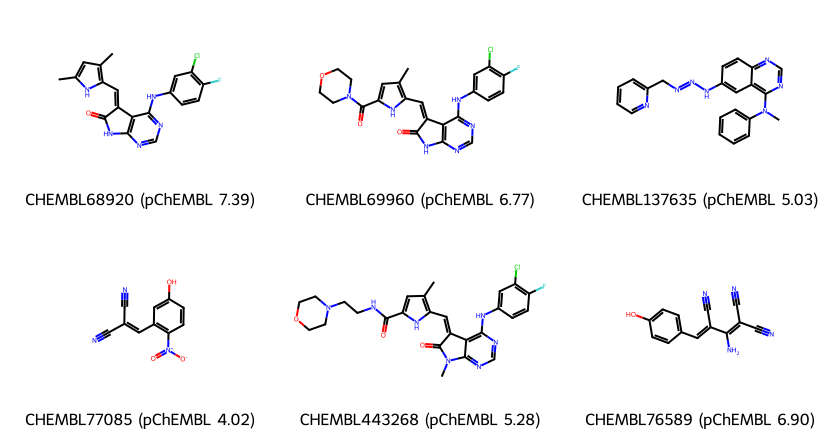

In [8]:
def draw_candidates(result, max_n=6):
    ch = None
    for t in result["trace"]:
        if t["tool"] == "search_chembl_actives": ch = t["obs"]
    if not ch or not ch.get("actives"):
        print("그릴 후보 없음"); return None
    mols, legends = [], []
    for a in ch["actives"][:max_n]:
        m = Chem.MolFromSmiles(a["canonical_smiles"])
        if m is None: continue
        mols.append(m)
        legends.append(f"{a['molecule_chembl_id']} (pChEMBL {a.get('pchembl_value','?')})")
    if not mols:
        print("유효 구조 없음"); return None
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(280, 220), legends=legends)
    return img

img = draw_candidates(result)
img  # 마지막 표현식 → 노트북 출력에 PNG 임베드


## 5. 에이전트 고도화

실전 에이전트는 (1) 새 도구를 계속 붙이고, (2) 도구 실패를 스스로 회복하며, (3) 안전하게 운영된다.

### 5-1. 도구 추가하기
도구 추가 = **함수 구현 + JSON schema 등록 + dispatch 매핑**, 이 3단계뿐이다.
아래는 PubChem으로 화합물 이름/CID를 조회하는 새 도구를 붙이는 예시 (실제 PubChem PUG-REST 호출).

In [9]:
# (1) 새 도구 함수 — 실제 PubChem PUG-REST
def pubchem_lookup(name: str) -> dict:
    """화합물 이름 → PubChem CID + canonical SMILES + 분자식 (실 API)."""
    base = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"
    try:
        url = f"{base}/compound/name/{requests.utils.quote(name)}/property/CanonicalSMILES,MolecularFormula/JSON"
        r = requests.get(url, headers=UA, timeout=20)
        r.raise_for_status()
        props = r.json()["PropertyTable"]["Properties"][0]
        return {"name": name, "cid": props.get("CID"),
                "smiles": props.get("CanonicalSMILES"),
                "formula": props.get("MolecularFormula"),
                "provenance": "PubChem PUG-REST"}
    except Exception as e:
        return {"name": name, "error": f"{type(e).__name__}: {e}", "provenance": "PubChem (failed)"}

# (2) 스키마 등록  (3) dispatch 매핑
TOOLS_SCHEMA.append({
    "name": "pubchem_lookup",
    "description": "Look up a compound by name in PubChem. Returns CID, canonical SMILES, molecular formula.",
    "input_schema": {"type": "object", "properties": {"name": {"type": "string"}}, "required": ["name"]}})
TOOL_FUNCS["pubchem_lookup"] = pubchem_lookup

# 즉시 사용 가능
print("도구 추가 후 총", len(TOOL_FUNCS), "개")
print(call_tool("pubchem_lookup", {"name": "gefitinib"}))


도구 추가 후 총 6 개


{'name': 'gefitinib', 'cid': 123631, 'smiles': None, 'formula': 'C22H24ClFN4O3', 'provenance': 'PubChem PUG-REST'}


### 5-2. 실패 디버깅 — 재시도 & 폴백
네트워크 도구는 실패할 수 있다. 견고한 에이전트는 **지수 백오프 재시도** 후에도 실패하면
**대체 도구로 폴백** 한다 (그리고 수치를 지어내지 않는다).

In [10]:
def with_retry(fn, *args, tries=3, base_delay=0.6, **kw):
    """지수 백오프 재시도. 마지막 시도까지 실패하면 마지막 error 결과를 반환."""
    last = None
    for i in range(tries):
        obs = fn(*args, **kw)
        if "error" not in obs:
            if i: print(f"   재시도 {i}회 후 성공")
            return obs
        last = obs
        print(f"   시도 {i+1}/{tries} 실패: {obs.get('error','')[:60]} — {base_delay*2**i:.1f}s 대기")
        time.sleep(base_delay * 2 ** i)
    return last

def resolve_smiles(identifier: str) -> dict:
    """SMILES 확보: ChEMBL 우선 → 실패 시 PubChem 폴백 (무-날조: 둘 다 실패하면 error)."""
    # 일부러 실패하는 도구를 넣어 폴백을 시연
    def _broken(x): return {"error": "simulated outage"}
    obs = with_retry(_broken, identifier, tries=2)
    if "error" in obs:
        print("   → ChEMBL 계열 실패, PubChem으로 폴백")
        obs = with_retry(pubchem_lookup, identifier, tries=2)
    return obs

print("데모: 'imatinib' SMILES 확보 (1차 실패 → 폴백)")
r = resolve_smiles("imatinib")
print("결과:", {k: (str(v)[:50] if k=='smiles' else v) for k, v in r.items()})


데모: 'imatinib' SMILES 확보 (1차 실패 → 폴백)
   시도 1/2 실패: simulated outage — 0.6s 대기


   시도 2/2 실패: simulated outage — 1.2s 대기


   → ChEMBL 계열 실패, PubChem으로 폴백


결과: {'name': 'imatinib', 'cid': 5291, 'smiles': 'None', 'formula': 'C29H31N7O', 'provenance': 'PubChem PUG-REST'}


### 5-3. 자사 데이터 시나리오 & 안전(safety)

**자사 데이터로 확장:** 위 도구들의 API 호출부를 사내 자원으로 바꾸면 그대로 사내 에이전트가 된다 —
예) `search_chembl_actives` → 사내 HTS/어세이 DB 쿼리, `lookup_uniprot` → 사내 타겟 카드,
`search_pubmed` → 사내 문서 RAG(내부 보고서 벡터 검색). **스키마/dispatch 구조는 동일**하다.

**안전 3원칙 (실전 배치 시 필수):**
1. **권한 최소화(least privilege)** — 도구는 필요한 최소 범위만. 쓰기/삭제·결제·이메일 발송 등
   부작용 있는 도구는 사람 승인(HITL) 게이트 뒤에 둔다. (읽기 전용 우선)
2. **키 격리(secret isolation)** — API 키는 `os.environ`/시크릿 매니저로만. **코드·노트북·로그에 하드코딩 금지**,
   깃 커밋 금지. 이 노트북은 `getpass`/환경변수만 사용한다.
3. **감사 로그(audit trail)** — 모든 `{tool, args, obs, provenance, timestamp}` 를 남겨 재현·추적 가능하게.
   아래는 최소 감사 로거 예시.

In [11]:
import datetime
AUDIT_LOG = []
def audited_call(name, args):
    rec = {"ts": datetime.datetime.utcnow().isoformat() + "Z", "tool": name, "args": args}
    obs = call_tool(name, args)
    rec["ok"] = "error" not in obs
    rec["provenance"] = obs.get("provenance")
    AUDIT_LOG.append(rec)
    return obs

_ = audited_call("mol_properties", {"smiles": "CC(=O)Oc1ccccc1C(=O)O"})  # aspirin
_ = audited_call("lookup_uniprot", {"gene_or_id": "EGFR"})
print(json.dumps(AUDIT_LOG, indent=2, ensure_ascii=False))


/tmp/ipykernel_1878451/1416233838.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = {"ts": datetime.datetime.utcnow().isoformat() + "Z", "tool": name, "args": args}


[
  {
    "ts": "2026-08-31T14:28:19.052798Z",
    "tool": "mol_properties",
    "args": {
      "smiles": "CC(=O)Oc1ccccc1C(=O)O"
    },
    "ok": true,
    "provenance": "RDKit Descriptors/QED (real computation)"
  },
  {
    "ts": "2026-08-31T14:28:19.055547Z",
    "tool": "lookup_uniprot",
    "args": {
      "gene_or_id": "EGFR"
    },
    "ok": true,
    "provenance": "UniProt REST (P00533)"
  }
]


## 6. 한계와 주의 (반드시 읽기)

- **환각(hallucination):** LLM은 그럴듯한 가짜 PMID/ChEMBL ID/IC50를 만들어낼 수 있다.
  이 노트북은 그래서 **수치·식별자를 전부 도구(실 API/RDKit)에서만** 가져오고, 보고서 조립도 트레이스 값만 쓴다.
  실전에서도 "LLM이 말한 수치"는 **항상 도구로 재검증** 해야 한다.
- **규칙기반 ADMET의 한계:** `admet_flags`는 Lipinski/Veber/lead-like **규칙 필터**다. 실제 흡수·분포·대사·배설·독성은
  이 규칙으로 알 수 없다 — 전용 ML 모델(예: ADMET-AI/TxGemma류)이나 실험이 필요하다. "예측"이라 부르지 말 것.
- **pChEMBL/활성값:** 서로 다른 어세이·조건의 집계라 화합물 간 직접 비교에 주의. 단위·relation(`=`/`>`) 확인 필수.
- **검증(verification) 필요:** 에이전트 산출물은 **가설**이다. 신약 발견이 아니라 알려진 화학공간의 정리·선별 시연이다.
- **재현성:** 네트워크 상태·DB 업데이트로 반환 화합물이 달라질 수 있다. 감사 로그와 timestamp로 추적한다.

### 다음 단계
- `pde5_harness/` — 같은 원리를 Claude Code **하네스**(CLAUDE.md 규약 + 검증 훅)로 구현한 버전.
  자연어 지시 하나로 PLAN→검증 게이트→보고서까지 자율 실행한다. (실습 가이드: `pde5_harness_실습가이드.md`)
- 다중 에이전트(co-scientist): 가설 생성/비평/랭킹을 여러 에이전트로 분업 (2026 트렌드).

---
*무-날조 원칙 준수: 이 노트북의 모든 값은 실제 API 응답 또는 RDKit 실계산이다.*